# Setting up environment

In [6]:
!git config --global user.email "Seifomara9@gmail.com"
!git config --global user.name "Seifomara"

In [7]:
!git clone https://github.com/Seifomara/ML-fundamentals-2026.git

fatal: destination path 'ML-fundamentals-2026' already exists and is not an empty directory.


In [8]:
from google.colab import userdata
token = userdata.get('PAT')
!git remote set-url origin https://{token}@github.com/Seifomara/ML-fundamentals-2026.git
!git push origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
drive.mount('/content/drive')

Mounted at /content/drive


#Identifying the prediction target






Our target variable = "y"

"y" is our binary ("yes"/"no") target variable our model will try to predict as the campaigns obvjective is predicting subscribitions before/during campaign.





Superficially valid target variables


*   poutcome (outcome of the previous marketing campaign): should not be our target variable as we're trying to predict current campaign not past.
*   duration (last contact duration, in seconds): should not be our target variable as we're trying to predict wether customer subscribes and not how long the call will last

# Data loading and exploration

In [11]:
df = pd.read_csv("bank-additional.csv",sep=';')

In [12]:
df.shape #number of rows, columns

(4119, 21)

In [13]:
df.dtypes #column types

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [14]:
df.describe()  # summary statistics for numerical columns


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [15]:
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [16]:
df['y'].value_counts()

,count
y,
no,3668
yes,451


Theres a significant class inbalance in our target variable with 89.05% "no"

In [17]:
df.isnull().sum()  # explicit missing values (NaN)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [18]:
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns")

job: 39 unknowns
marital: 11 unknowns
education: 167 unknowns
default: 803 unknowns
housing: 105 unknowns
loan: 105 unknowns


Missing values:


* job: 39 unknowns
* marital: 11 unknowns
* education: 167 unknowns
* default: 803 unknowns
* housing: 105 unknowns
* loan: 105 unknowns



**numerical variables distribution**

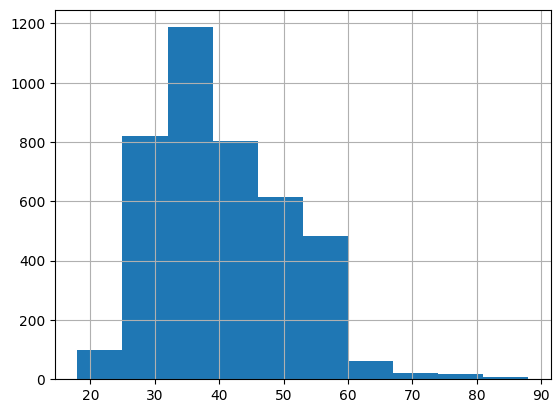

In [19]:
df['age'].hist()
plt.show()

the distribution of numerical variable age is bell shaped, right-skewed with a long tail to the right going up to 90. Which suggests we would need to feature sclaing

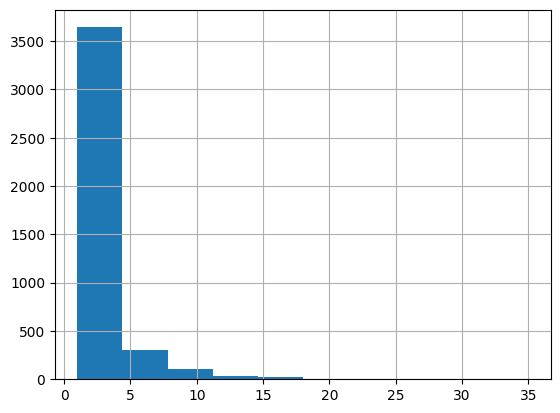

In [20]:
df['campaign'].hist()
plt.show()

In [21]:
df['campaign'].max()

35

the distribution of numerical variable campaign is concentrated between 1 and 4. which means most people were contacted from 1-4 times however it is also very right-skewed with extreme outliers going up to 35. Someone was contacted 35 times.

**categorical variables distribution**



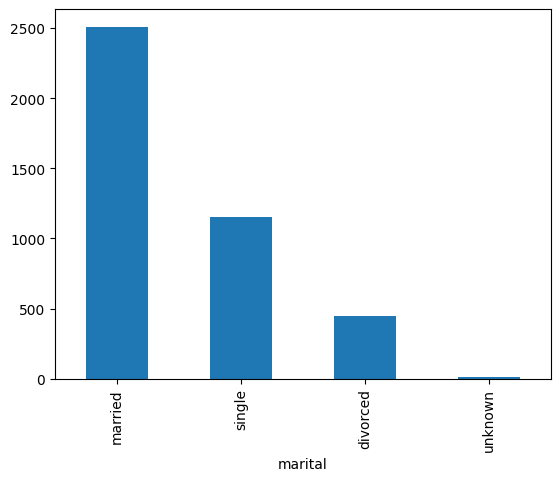

In [22]:
df['marital'].value_counts().plot(kind='bar')
plt.show()

most of our individuals contacted are married

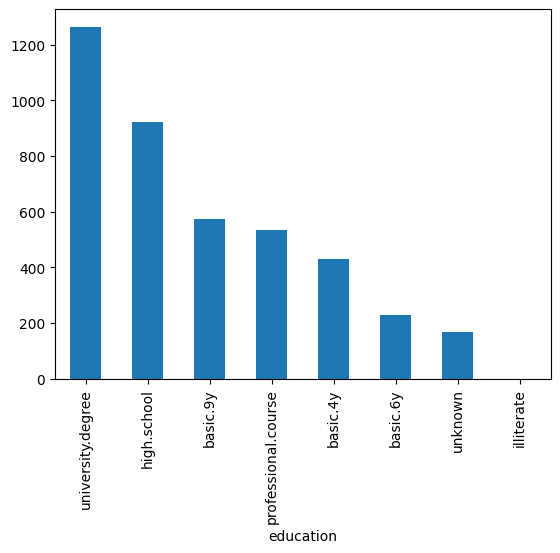

In [23]:
df['education'].value_counts().plot(kind='bar')
plt.show()

most common degree is university degree, with the next most common is highschool. this variable is an ordinal variable (categories with a meaningful order). Theres also unknown values which represents missing values.

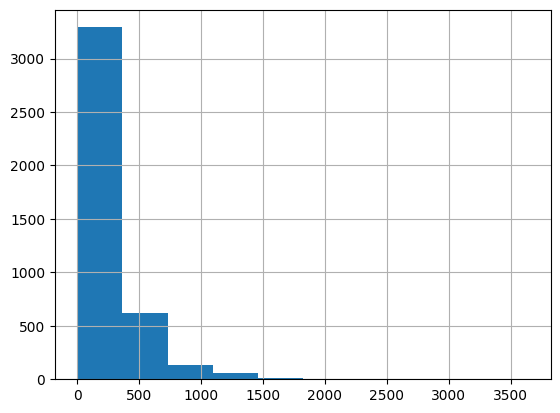

In [24]:
df['duration'].hist()
plt.show()

a variable that will require special attention is "duration" as its right-skewed, and its availibilty is at prediction time

# Data Splitting

I will split the data 60/20/20. Which gives 2471 rows for training, 824 rows for validating, and 824 rows for testing.

We will also need to stratify to solve our class inbalance issue

In [25]:
X = df.drop(columns=['y'])
y = df['y']

In [26]:
#test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

#training and validation
X_train, X_val, y_train, y_val = train_test_split(
X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full,
)

In [27]:
#verify split
print(X_train.shape, X_val.shape, X_test.shape)

(2471, 20) (824, 20) (824, 20)


In [28]:
#verify stratify
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


We split our data at this stage of the pipeline, before handling missing values as if we did handle missing values, we would be using information from our test set. Also scaling before splitting leaks info like mean and std.

In [29]:
!cp "/content/drive/MyDrive/Colab Notebooks/assignment_1_<Seif_Omara_[Omara]>.ipynb" /content/ML-fundamentals-2026/assignment_1_Seif_Omara.ipynb

In [30]:
!git add assignment_1_Seif_Omara.ipynb
!git commit -m "Implemented until Data Splitting: 60/20/20 stratified split"
!git pull
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


# Managing missing values

In [31]:
df.isnull().sum()  #(NaN)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [32]:
for col in X_train.select_dtypes(include='object').columns:
    unknown_count = (X_train[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns")

job: 19 unknowns
marital: 5 unknowns
education: 89 unknowns
default: 478 unknowns
housing: 57 unknowns
loan: 57 unknowns


In [33]:
X_train['pdays'].value_counts().head()


,count
pdays,
999,2365
3,32
6,31
4,11
7,7


**Missing Values Strategies**


*  "defualt", "housing", "loan": keep "unknown" as a separate category as if someone's default status is unknown, that might actually mean something
*   "job", "marital", "education": i'll impute with most frequent value as there is small % of unknowns

* "pdays" has a numerical sentintal value of 999, which means the client was never contacted. so i'll create a binary indactor variable (1 = contacted, 0 = never contacted)






In [34]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='unknown')

cols_to_impute = ['job', 'marital', 'education']

X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_val[cols_to_impute] = imputer.transform(X_val[cols_to_impute])
X_test[cols_to_impute] = imputer.transform(X_test[cols_to_impute])

The SimpleImputer was trained on the training set only, as training on the complete dataset would leak information about the validation and test sets into the imputation process - the most common value would be biased by unknown data.

In [35]:
for dataset in [X_train, X_val, X_test]:
    dataset['pdays_contacted'] = (dataset['pdays'] != 999).astype(int)
    dataset.drop(columns=['pdays'], inplace=True)

In [60]:
%cd /content/ML-fundamentals-2026

/content/ML-fundamentals-2026


In [61]:
!git remote set-url origin https://{token}@github.com/Seifomara/ML-fundamentals-2026.git
!git push origin main

Everything up-to-date


In [38]:
!git add assignment_1_Seif_Omara.ipynb
!git commit -m "Managed missing values"
!git pull
!git push

[main 344035c] Managed missing values
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite assignment_1_Seif_Omara.ipynb (95%)
Already up to date.
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 3.37 KiB | 863.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Seifomara/ML-fundamentals-2026.git
   4ac1d40..344035c  main -> main


# Encoding Categorical Variables

So we noticed that education is ordinal earlies but lets check if there are more.

In [39]:
X_train.select_dtypes(include='object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

Even though "month" and "day_of_week" have a natural order, it is considered nominal. so "education" is our only ordinal variable. So for education our strategy is ordinal encoding. And the rest One-Hot Encoding.  

In [40]:

education_order = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'unknown']]

ordinal_encoder = OrdinalEncoder(categories=education_order)

X_train['education'] = ordinal_encoder.fit_transform(X_train[['education']])
X_val['education'] = ordinal_encoder.transform(X_val[['education']])
X_test['education'] = ordinal_encoder.transform(X_test[['education']])

In [41]:
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training, transform all sets
ohe_train = pd.DataFrame(ohe.fit_transform(X_train[nominal_cols]), columns=ohe.get_feature_names_out(nominal_cols), index=X_train.index)
ohe_val = pd.DataFrame(ohe.transform(X_val[nominal_cols]), columns=ohe.get_feature_names_out(nominal_cols), index=X_val.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[nominal_cols]), columns=ohe.get_feature_names_out(nominal_cols), index=X_test.index)

# Drop original columns and add encoded ones
X_train = pd.concat([X_train.drop(columns=nominal_cols), ohe_train], axis=1)
X_val = pd.concat([X_val.drop(columns=nominal_cols), ohe_val], axis=1)
X_test = pd.concat([X_test.drop(columns=nominal_cols), ohe_test], axis=1)

In [42]:
X_train.shape

(2471, 53)

We went from 20 columns to 53. This is because One-Hot Encoding has formed a new binary column with each category. The dimensionality was changed to 53 features. Training data was only fitted with encoders so that leakage would not occur. Logistic Regression draws a linear line of decision (hyperplane). In the case of One-Hot Encoding, categories are replaced by distinct binary features and therefore the model can give a different coefficient to each category.
For example, in "job", we do not have  one column with numbers 1-10 but several columns such as "job_admin", "job_blue-collar", etc.. With each each havingits own weight.
In the case of "education" that uses Ordinal Encoding, it considered as  numerical characteristic with a linear interaction, for example:  the more education one has the higher the number, the more/less likely the individual would subscribe.


In [43]:
X_train.dtypes

,0
age,int64
education,float64
duration,int64
campaign,int64
previous,int64
emp.var.rate,float64
cons.price.idx,float64
cons.conf.idx,float64
euribor3m,float64
nr.employed,float64


# Feature scaling

In [48]:
X_train.select_dtypes(include=['int64', 'float64']).columns

Index(['age', 'education', 'duration', 'campaign', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'pdays_contacted', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'marital_divorced', 'marital_married', 'marital_single', 'default_no',
       'default_unknown', 'housing_no', 'housing_unknown', 'housing_yes',
       'loan_no', 'loan_unknown', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu',
       'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure',
       'poutcome_nonexistent', 'poutcome_success'],
      dtype='object')

We will now begin with feature scaling. As our variables are not on the same scale, our model will assign larger weights to smaller-scale features.

the variables we will scale are:


* age education
* campaign
* previous
* emp.var.rate
* cons.price.idx
* cons.conf.idx
* euribor3m
* nr.employed

We will standarize these variables to have a mean of 0 and sd of 1

Transformation is done on training set to avoid data leakage.

**Feature scaling**


*   Logistic regression is gradient-based optimization
*   We need to be able to compare variables on different scales, e.g. age (18-90) and emp.var. (-3 to +2)
*   For fair regularizaton penalties for feature coef.






In [50]:

cols_to_scale = ['age', 'education', 'campaign', 'previous', 'emp.var.rate',
                 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Feature Selection

In [52]:
#variables with low variance
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train)

low_variance_cols = X_train.columns[~var_selector.get_support()]
print(low_variance_cols)


Index(['month_dec'], dtype='object')


I chose 0.01 as a threshold to as this is less than 1% of our sample

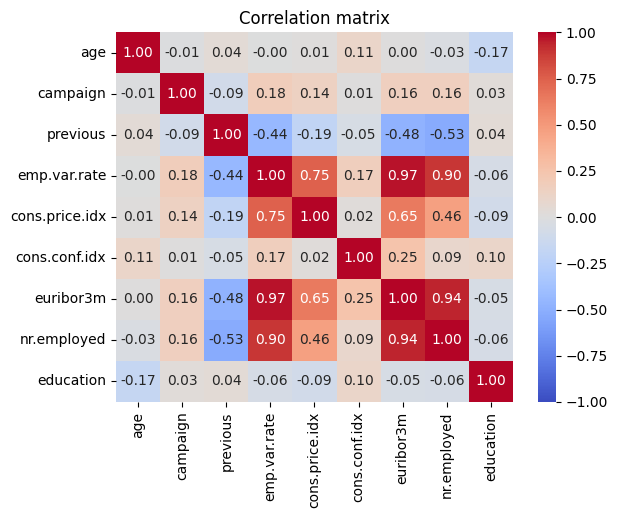

In [57]:
#corr matrix
numerical_cols = ['age', 'campaign', 'previous', 'emp.var.rate',
                  'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'education']

sns.heatmap(X_train[numerical_cols].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt='.2f')
plt.title("Correlation matrix")
plt.show()

The highly correlated pairs are:

emp.var.rate and euribor3m
emp.var.rate and nr.employed
euribor3m and nr.employed

I will choose to keep nr.employed because the number of employed in the economy directly measures econonimc

We will also drop "duration" as this variable is only available at prediction time

Furthermore, feature selection is only done on training data to not cause data leakage to our test set

In [58]:
X_train = X_train.drop(columns=['emp.var.rate', 'euribor3m', 'month_dec', 'duration'])
X_val = X_val.drop(columns=['emp.var.rate', 'euribor3m', 'month_dec', 'duration'])
X_test = X_test.drop(columns=['emp.var.rate', 'euribor3m', 'month_dec', 'duration'])

In [62]:
!git add assignment_1_Seif_Omara.ipynb
!git commit -m "Feature scaling/selection"
!git pull
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Already up to date.
Everything up-to-date
